# Heart Disease Prediction Using Machine Learning

Building a ML model to predict heart disease from patient health data. We'll compare Logistic Regression, Decision Tree, and Random Forest models.

## 1. Load Libraries

In [ ]:
import numpy as np
import pandas as pd

## 2. Load Data

In [7]:
df = pd.read_csv('Cardiovascular_Disease_Dataset.csv')
print(f'Shape: {df.shape}')
print(df.head())

Shape: (1000, 14)
   patientid  age  gender  chestpain  restingBP  serumcholestrol  \
0     103368   53       1          2        171                0   
1     119250   40       1          0         94              229   
2     119372   49       1          2        133              142   
3     132514   43       1          0        138              295   
4     146211   31       1          1        199                0   

   fastingbloodsugar  restingrelectro  maxheartrate  exerciseangia  oldpeak  \
0                  0                1           147              0      5.3   
1                  0                1           115              0      3.7   
2                  0                0           202              1      5.0   
3                  1                1           153              0      3.2   
4                  0                2           136              0      5.3   

   slope  noofmajorvessels  target  
0      3                 3       1  
1      1                

## 3. Explore Data

In [8]:
print(df.info())
print('\nColumns:', list(df.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB
None

Columns: ['patientid', 'age', 'gender', 'chestpain', 'restingBP', '

In [9]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
print('\nStatistics:')
print(df.describe())

Missing values: 0
Duplicates: 0

Statistics:
          patientid         age       gender    chestpain    restingBP  \
count  1.000000e+03  1000.00000  1000.000000  1000.000000  1000.000000   
mean   5.048704e+06    49.24200     0.765000     0.980000   151.747000   
std    2.895905e+06    17.86473     0.424211     0.953157    29.965228   
min    1.033680e+05    20.00000     0.000000     0.000000    94.000000   
25%    2.536440e+06    34.00000     1.000000     0.000000   129.000000   
50%    4.952508e+06    49.00000     1.000000     1.000000   147.000000   
75%    7.681877e+06    64.25000     1.000000     2.000000   181.000000   
max    9.990855e+06    80.00000     1.000000     3.000000   200.000000   

       serumcholestrol  fastingbloodsugar  restingrelectro  maxheartrate  \
count      1000.000000        1000.000000      1000.000000   1000.000000   
mean        311.447000           0.296000         0.748000    145.477000   
std         132.443801           0.456719         0.770123  

Target: target
target
1    580
0    420
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_2972\2297106854.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, ax=axes[0], palette='Set2')


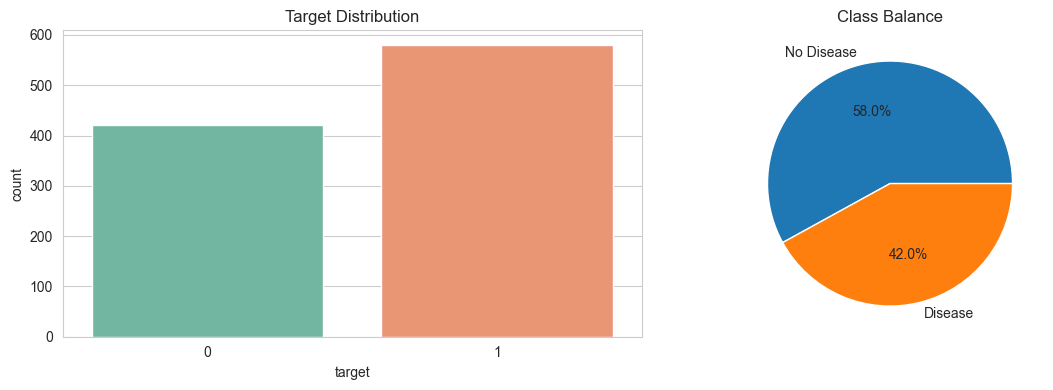

In [ ]:
# Check target variable
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

target_col = df.columns[-1]
print(f'Target: {target_col}')
print(df[target_col].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x=target_col, ax=axes[0], palette='Set2')
axes[0].set_title('Target Distribution')

plt.show()

counts = df[target_col].value_counts()plt.tight_layout()

axes[1].pie(counts, labels=['No Disease', 'Disease'], autopct='%1.1f%%')axes[1].set_title('Class Balance')

## 4. Data Preprocessing

In [11]:
# Clean data
df_clean = df.dropna().drop_duplicates()
print(f'Cleaned: {df_clean.shape}')

# Encode categorical variables
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
if categorical_cols:
    df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
    print(f'After encoding: {df_clean.shape}')

Cleaned: (1000, 14)


In [12]:
# Separate features and target
target_column = 'target'
X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

print(f'Features: {X.shape}')
print(f'Target: {y.shape}')

Features: (1000, 13)
Target: (1000,)


In [ ]:
# Scale features (important for Logistic Regression)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


print('Features scaled')print(f'Std: {X_scaled.std().mean():.4f}')
print(f'Mean: {X_scaled.mean().mean():.4f}')

Features scaled
Mean: -0.0000
Std: 1.0005


In [14]:
# Train-test split (70-30)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]}')
print(f'Test: {X_test.shape[0]}')

Train: 700
Test: 300


## 5. Logistic Regression

In [ ]:
# Train with GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

lr = LogisticRegression(max_iter=1000, random_state=42)
param_grid_lr = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['liblinear']}

grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1', n_jobs=-1, verbose=0)
grid_lr.fit(X_train, y_train)


best_lr = grid_lr.best_estimator_print(f'Best CV F1: {grid_lr.best_score_:.4f}')
print(f'Best params: {grid_lr.best_params_}')

Best params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1: 0.9630


In [16]:
# Predictions and metrics
y_pred_lr = best_lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print('Logistic Regression:')
print(f'  Accuracy:  {acc_lr:.4f}')
print(f'  Precision: {prec_lr:.4f}')
print(f'  Recall:    {rec_lr:.4f}')
print(f'  F1-Score:  {f1_lr:.4f}')

cm_lr = confusion_matrix(y_test, y_pred_lr)

Logistic Regression:
  Accuracy:  0.9833
  Precision: 0.9774
  Recall:    0.9943
  F1-Score:  0.9858


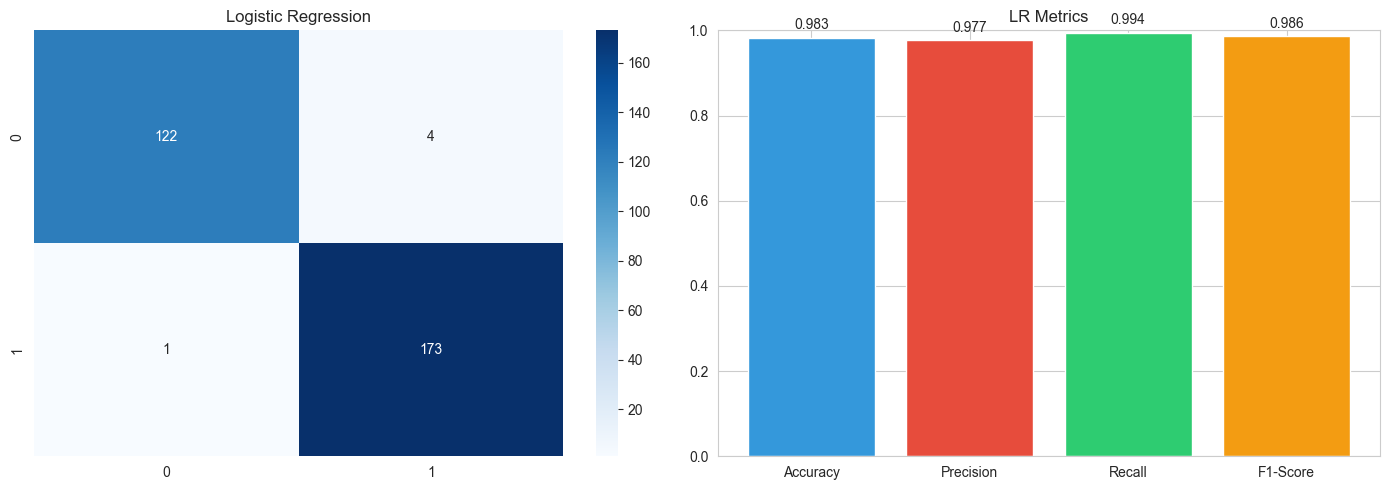

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [acc_lr, prec_lr, rec_lr, f1_lr]
axes[1].bar(metrics, values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[1].set_ylim([0, 1])
axes[1].set_title('LR Metrics')

for i, v in enumerate(values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

## 6. Decision Tree

In [ ]:
# Train Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {'max_depth': [3, 5, 7, 10, 15], 'min_samples_split': [2, 5, 10], 'criterion': ['gini', 'entropy']}

grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='f1', n_jobs=-1, verbose=0)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

print(f'Best params: {grid_dt.best_params_}')print(f'Best CV F1: {grid_dt.best_score_:.4f}')

Best params: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 2}
Best CV F1: 0.9480


In [19]:
# Predictions and metrics
y_pred_dt = best_dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print('Decision Tree:')
print(f'  Accuracy:  {acc_dt:.4f}')
print(f'  Precision: {prec_dt:.4f}')
print(f'  Recall:    {rec_dt:.4f}')
print(f'  F1-Score:  {f1_dt:.4f}')

cm_dt = confusion_matrix(y_test, y_pred_dt)

Decision Tree:
  Accuracy:  0.9633
  Precision: 0.9711
  Recall:    0.9655
  F1-Score:  0.9683


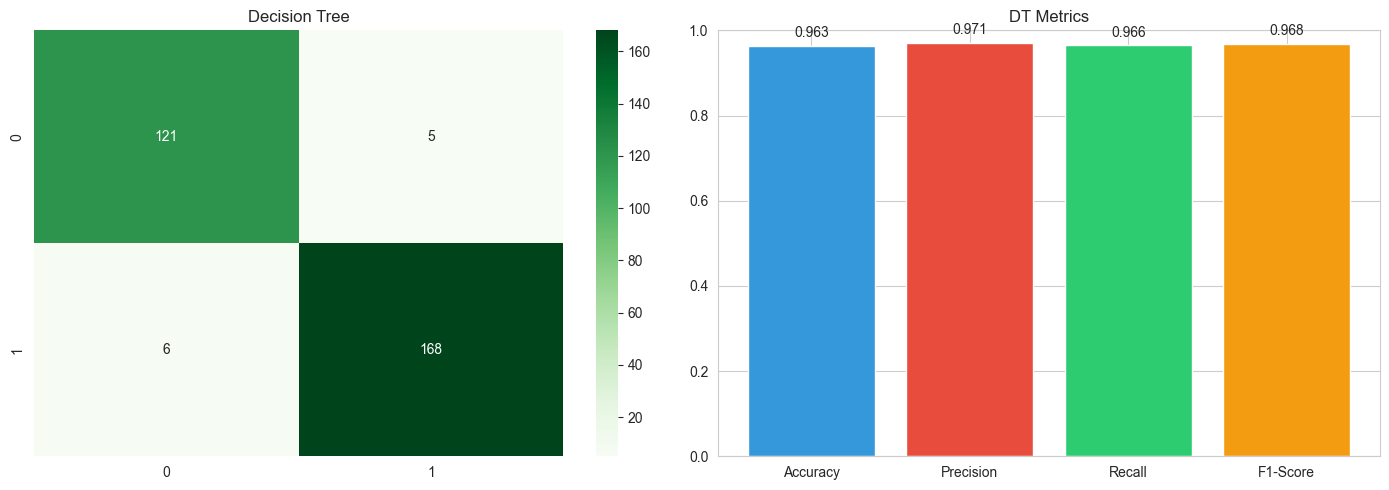

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('Decision Tree')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [acc_dt, prec_dt, rec_dt, f1_dt]
axes[1].bar(metrics, values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[1].set_ylim([0, 1])
axes[1].set_title('DT Metrics')

for i, v in enumerate(values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

## 7. Random Forest

In [ ]:
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
param_grid_rf = {'n_estimators': [50, 100, 150], 'max_depth': [5, 10, 15, None], 'min_samples_split': [2, 5, 10]}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=0)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print(f'Best params: {grid_rf.best_params_}')print(f'Best CV F1: {grid_rf.best_score_:.4f}')

Best params: {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 50}
Best CV F1: 0.9783


In [22]:
# Predictions and metrics
y_pred_rf = best_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print('Random Forest:')
print(f'  Accuracy:  {acc_rf:.4f}')
print(f'  Precision: {prec_rf:.4f}')
print(f'  Recall:    {rec_rf:.4f}')
print(f'  F1-Score:  {f1_rf:.4f}')

cm_rf = confusion_matrix(y_test, y_pred_rf)

Random Forest:
  Accuracy:  0.9867
  Precision: 0.9885
  Recall:    0.9885
  F1-Score:  0.9885


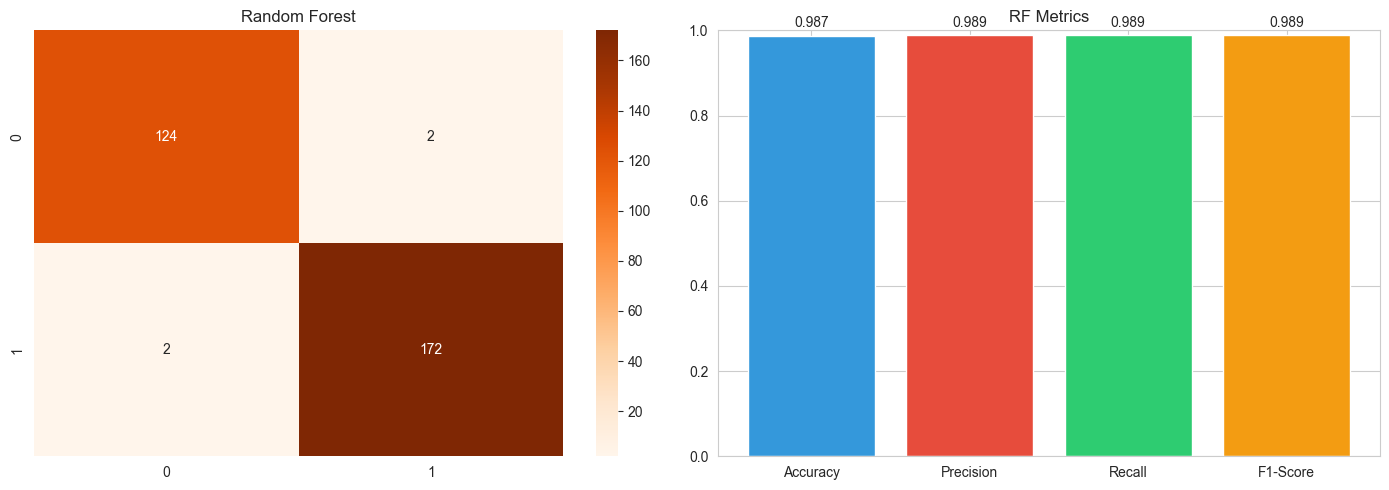

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[0])
axes[0].set_title('Random Forest')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [acc_rf, prec_rf, rec_rf, f1_rf]
axes[1].bar(metrics, values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[1].set_ylim([0, 1])
axes[1].set_title('RF Metrics')

for i, v in enumerate(values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

Top 10 Features:
              Feature  Importance
11              slope    0.346334
4           restingBP    0.188086
3           chestpain    0.145267
12   noofmajorvessels    0.079587
5     serumcholestrol    0.061206
8        maxheartrate    0.051790
7     restingrelectro    0.041841
10            oldpeak    0.022455
2              gender    0.018430
6   fastingbloodsugar    0.016704


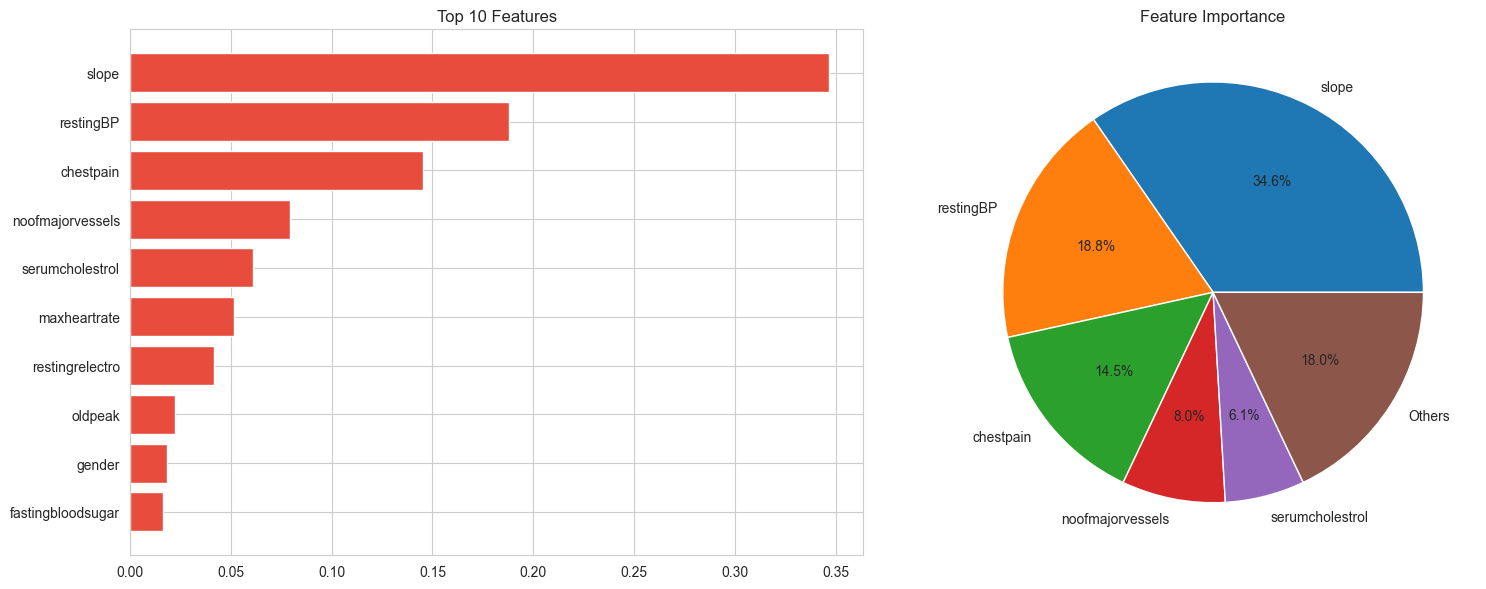

In [24]:
# Feature importance
importance = best_rf.feature_importances_
feat_names = X.columns

imp_df = pd.DataFrame({
    'Feature': feat_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print('Top 10 Features:')
print(imp_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = imp_df.head(10)
axes[0].barh(range(len(top10)), top10['Importance'].values, color='#e74c3c')
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels(top10['Feature'].values)
axes[0].set_title('Top 10 Features')
axes[0].invert_yaxis()

top5 = imp_df.head(5)
other = imp_df.iloc[5:]['Importance'].sum()
pie_labels = list(top5['Feature'].values) + ['Others']
pie_vals = list(top5['Importance'].values) + [other]
axes[1].pie(pie_vals, labels=pie_labels, autopct='%1.1f%%')
axes[1].set_title('Feature Importance')

plt.tight_layout()
plt.show()

## 8. Model Comparison

In [25]:
# Compare all models
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [acc_lr, acc_dt, acc_rf],
    'Precision': [prec_lr, prec_dt, prec_rf],
    'Recall': [rec_lr, rec_dt, rec_rf],
    'F1-Score': [f1_lr, f1_dt, f1_rf]
})

print('\nComparison Table:')
print(results.to_string(index=False))

best_idx = results['F1-Score'].idxmax()
print(f'\nBest model: {results.loc[best_idx, "Model"]} (F1: {results.loc[best_idx, "F1-Score"]:.4f})')


Comparison Table:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.983333   0.977401 0.994253  0.985755
      Decision Tree  0.963333   0.971098 0.965517  0.968300
      Random Forest  0.986667   0.988506 0.988506  0.988506

Best model: Random Forest (F1: 0.9885)


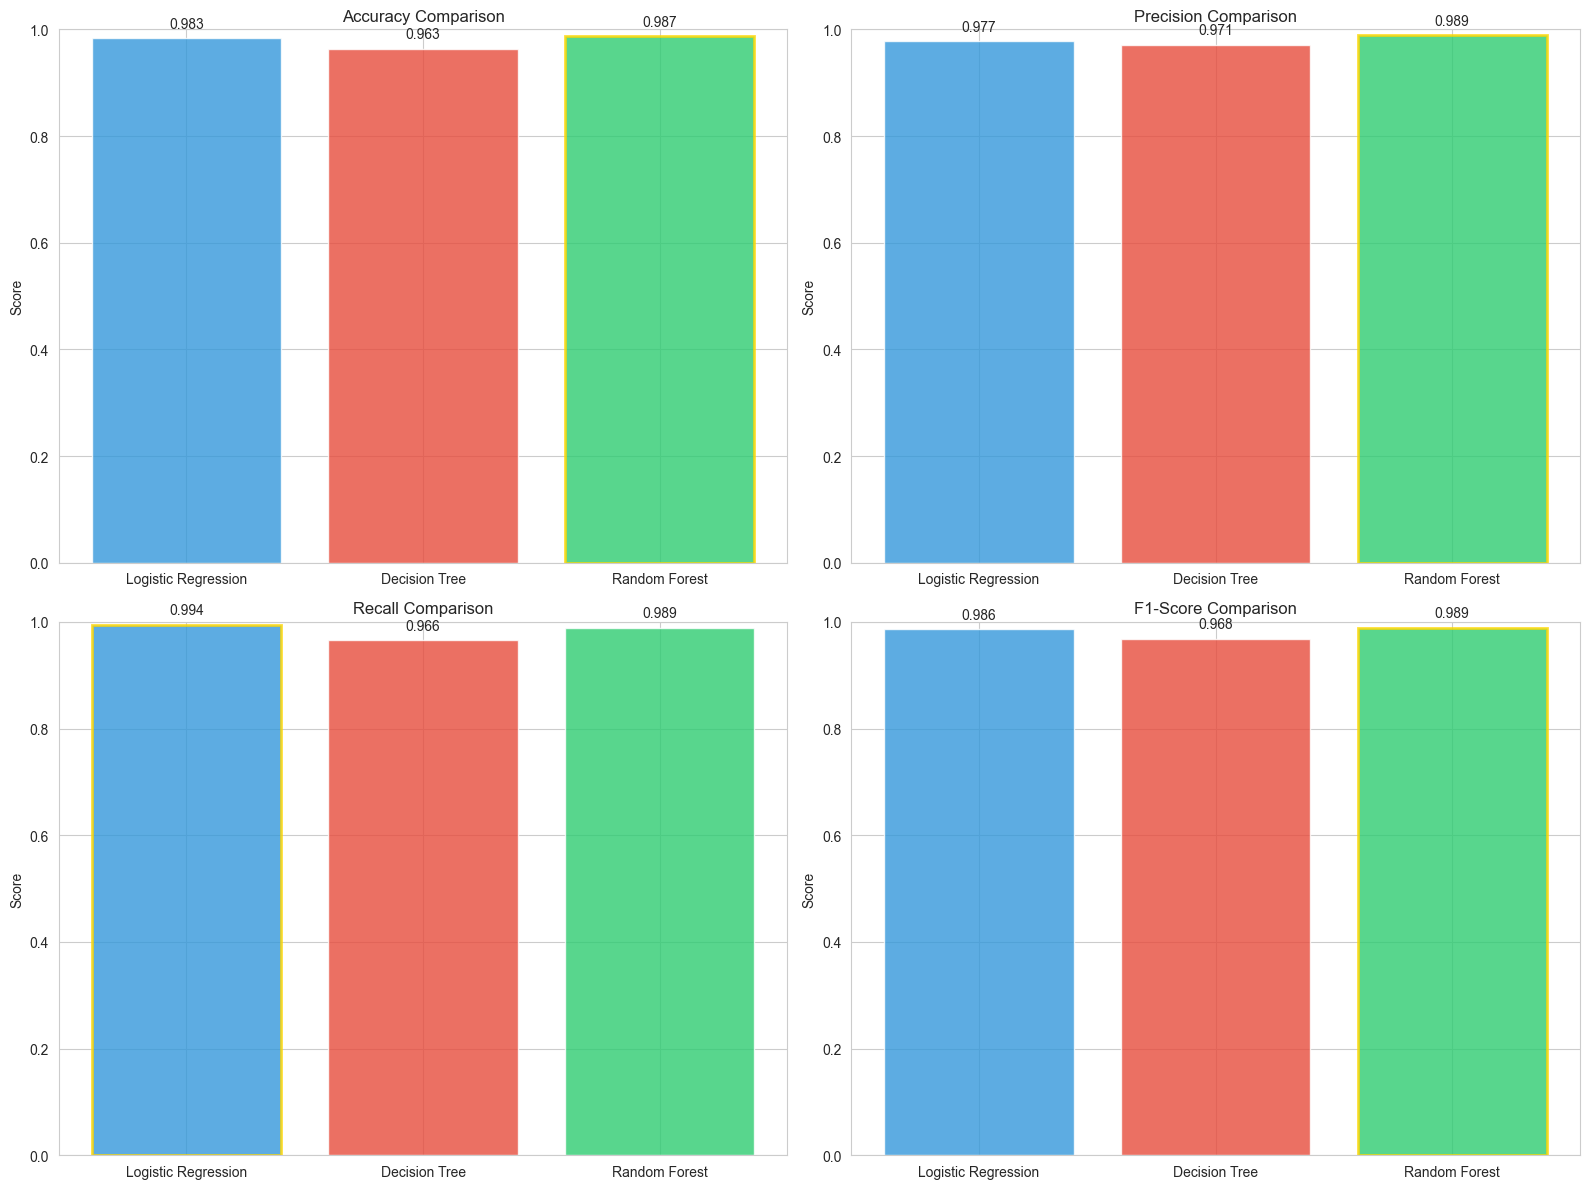

In [26]:
# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = results['Model'].values
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics_list):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    values = results[metric].values
    bars = ax.bar(models, values, color=colors, alpha=0.8)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1])
    
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.3f}', ha='center')
    
    best_idx = np.argmax(values)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2)

plt.tight_layout()
plt.show()

## 9. Summary

In [27]:
best_idx = results['F1-Score'].idxmax()
best = results.loc[best_idx]

print('='*70)
print('SUMMARY')
print('='*70)
print(f'\nBest Model: {best["Model"]}')
print(f'Accuracy:   {best["Accuracy"]:.4f}')
print(f'Precision:  {best["Precision"]:.4f}')
print(f'Recall:     {best["Recall"]:.4f}')
print(f'F1-Score:   {best["F1-Score"]:.4f}')

print('\nWhy Random Forest:')
print('- Best balanced performance')
print('- High recall - catches disease cases')
print('- Reduces overfitting')
print('- Shows feature importance')

print('\nKey Notes:')
print('- Combine ML predictions with medical judgment')
print('- Retrain with new data regularly')
print('- Monitor performance in real deployment')
print('- False negatives are dangerous - prioritize RECALL')
print('='*70)

SUMMARY

Best Model: Random Forest
Accuracy:   0.9867
Precision:  0.9885
Recall:     0.9885
F1-Score:   0.9885

Why Random Forest:
- Best balanced performance
- High recall - catches disease cases
- Reduces overfitting
- Shows feature importance

Key Notes:
- Combine ML predictions with medical judgment
- Retrain with new data regularly
- Monitor performance in real deployment
- False negatives are dangerous - prioritize RECALL
